In [11]:
from glob import glob

from collections import defaultdict
import numpy as np
import json
from _analysis import get_fid
import polars as pl
from sewar import msssim
from PIL import Image
from pathlib import Path
import tempfile
import io

from _plotting import plot_tradeoff

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get SSIM

In [12]:
usr_dir = "/home/weissl"
origins = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_yo/*_runs/*/*/origin*.png")
targets = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_yo/*_runs/*/*/taget*.png")

In [13]:
ssims = defaultdict(list)
for o, t in zip(origins, targets):
    key = o.split("_runs")[0].split("/")[-1]
    img1 = np.array(Image.open(o).convert("RGB"))
    img2 = np.array(Image.open(t).convert("RGB"))
    ssims[key].append(msssim(img1, img2).real)

## Get runtime data points

In [14]:
usr_dir = "/home/weissl"
stats = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_yo/*_runs/*/*/stats.json")

In [15]:
results = defaultdict(list)
for s in stats:
    key = s.split("_runs")[0].split("/")[-1]
    with open(s, "rb") as f:
        data = json.load(f)
    results[key].append(data["runtime"])

In [16]:
key_map = {float(k.split("_")[0]):k for k in results.keys()}

## Get FID

In [25]:
path = Path("guericke_partial.parquet")
if not path.exists():
    import fsspec
    fs = fsspec.filesystem("hf")
    files = fs.glob("datasets/cccccsys/guericke_dataset_2/data/train-*.parquet")
    df = pl.read_parquet([f"hf://{f}" for f in files[:5]])
    df = df.with_columns([
        pl.col("image").struct.field("bytes").alias("image_bytes"),
        pl.col("image").struct.field("path").alias("image_filename")
    ])
    df.write_parquet(path)
else:
    df = pl.read_parquet(path)

tmp_dir = Path(tempfile.mkdtemp())
imagenet_paths = []
for row in df.iter_rows(named=True):
    img = Image.open(io.BytesIO(row["image_bytes"])).convert("RGB")
    if img.size != (256, 256):
        img = img.resize((256, 256), Image.BILINEAR)
    path_file = tmp_dir / (Path(row["image_filename"]).stem + ".jpg")
    img.save(path_file, format="JPEG", quality=95)
    imagenet_paths.append(str(path_file))

In [26]:
sweep_path = "/home/weissl/Projects/SMOO/defaults/hynea/_sweep_yo/"
fid_by_lr = {}

for lr_dir in glob(f"{sweep_path}/*_runs"):
    lr_config = lr_dir.split("/")[-1].replace("_runs", "")
    targets = sorted(glob(f"{lr_dir}/*/*/taget*.png"))

    if targets:
        fid_score = get_fid(imagenet_paths, targets)
        fid_by_lr[lr_config]  = float(fid_score)

100%|██████████| 19/19 [00:05<00:00,  3.77it/s]


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


100%|██████████| 1/1 [00:00<00:00,  1.01it/s]
/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/pytorch_fid/fid_score.py:188: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


## Plot tradeoff

In [107]:
runt = [np.array(results[key_map[kr]]) for kr in sorted(key_map.keys())]
qual = [np.array(fid_by_lr[key_map[kr]]) for kr in sorted(key_map.keys())]
ssim = [np.array(ssims[key_map[kr]]) for kr in sorted(key_map.keys())]
ticks = [r"$\rightarrow$".join(key_map[kr].split("_")) for kr in sorted(key_map.keys())]

left_m = [(runt, "Runtime (sec)", (0-750 * 0.01, 750*1.01))]
right_m = [(qual, "FID", (247.5, 507.5)), (ssim, "MS-SSIM", (-0.01, 1.01))]

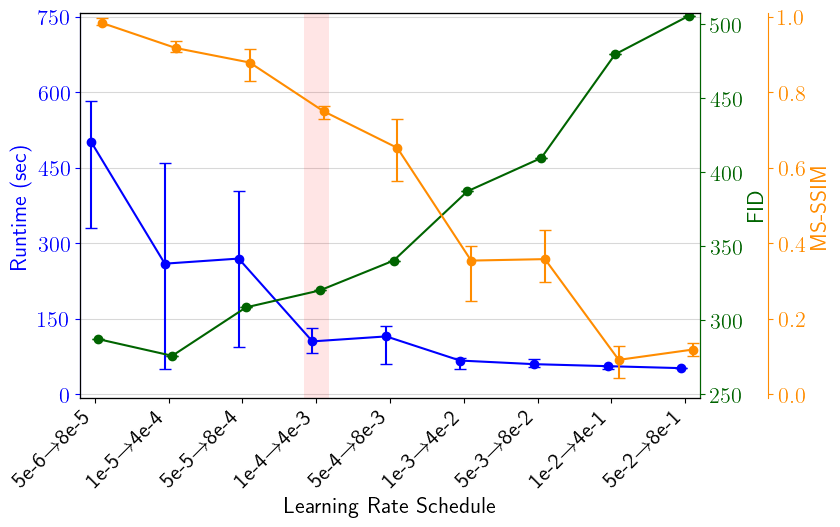

In [108]:
plot_tradeoff(left_m, right_m, ticks, colors=["blue", "darkgreen", "darkorange"], name="Yolo", vline=3)